# Personal Research Agent V2

V2 notebook with explicit quality hardening layers:
- planner -> parallel analyst interviews (hybrid subgraph)
- retrieval hardening and source/freshness policy gates
- validator classification + rejection tracking
- deterministic ranking/personalization + novelty memory
- V1-compatible outputs: report, newsletter, multilingual recap


## 1) Setup and Paths

This notebook is standalone under `projects/personal-research-agent-v2`.


In [37]:
from __future__ import annotations

import hashlib
import json
import operator
import os
import re
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict
from urllib.parse import urlparse, urlunparse

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from IPython.display import Image, Markdown, display

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, get_buffer_string
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch

try:
    from langchain_openai import ChatOpenAI
except Exception:
    ChatOpenAI = None

from langgraph.constants import Send
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph


/tmp/ipykernel_404024/3785959426.py:27: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [38]:
CWD = Path.cwd().resolve()


def locate_module_dir(cwd: Path) -> Path:
    candidates = []
    candidates.append(cwd)

    for base in [cwd, *cwd.parents]:
        candidates.append(base / "projects" / "personal-research-agent-v2")
        candidates.append(base / "personal-research-agent-v2")

    seen = set()
    for c in candidates:
        c = c.resolve()
        if c in seen:
            continue
        seen.add(c)
        if (c / "prompts").exists() and (c / "config").exists() and (c / "data").exists() and (c / "debug").exists():
            return c

    searched = "\n".join(f"- {str(x)}" for x in sorted(str(x) for x in seen))
    raise FileNotFoundError(
        "Could not locate personal-research-agent-v2 directory with prompts/config/data/debug. "
        f"CWD was: {cwd}\nSearched:\n{searched}"
    )


MODULE_DIR = locate_module_dir(CWD)

PROMPTS_DIR = MODULE_DIR / "prompts"
CONFIG_DIR = MODULE_DIR / "config"
DATA_DIR = MODULE_DIR / "data"
DEBUG_DIR = MODULE_DIR / "debug"

for env_path in [MODULE_DIR / ".env", MODULE_DIR.parent / ".env", MODULE_DIR.parent.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path, override=False)

for required in [PROMPTS_DIR, CONFIG_DIR, DATA_DIR, DEBUG_DIR]:
    assert required.exists(), f"Missing required directory: {required}"


def load_json(path: Path, default: Any) -> Any:
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def save_json(path: Path, payload: Any) -> None:
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=True, indent=2)


MODEL_CONFIG = load_json(CONFIG_DIR / "model_config.json", {})
SOURCE_POLICIES = load_json(CONFIG_DIR / "source_policies.json", {})

DEFAULTS = {
    "fast_model": "gemini-2.5-flash",
    "quality_model": "gemini-2.5-pro",
    "reasoning_model": "deepseek/deepseek-r1",
    "reasoning_provider": "openrouter",
    "reasoning_base_url": "https://openrouter.ai/api/v1",
    "reasoning_api_env": "OPENROUTER_API_KEY",
    "fallback_to_quality_on_reasoning_error": True,
    "enforce_reasoning_preflight": True,
    "warn_on_reasoning_fallback": True,
    "hard_fail_on_quality_gate": False,
    "temperature": 0,
    "max_results_per_query": 4,
    "max_num_turns": 2,
    "max_items_per_section": 4,
    "next_weekend_days": 2,
    "default_locations": ["Netherlands", "Limburg", "Maastricht", "Borgharen"],
    "default_languages": ["en", "it", "nl"],
}

for k, v in DEFAULTS.items():
    MODEL_CONFIG.setdefault(k, v)

print("Module directory:", MODULE_DIR)
print("GOOGLE_API_KEY loaded:", bool(os.getenv("GOOGLE_API_KEY")))
print("TAVILY_API_KEY loaded:", bool(os.getenv("TAVILY_API_KEY")))
print(f"{MODEL_CONFIG['reasoning_api_env']} loaded:", bool(os.getenv(MODEL_CONFIG["reasoning_api_env"])))


Module directory: /home/roberto/workspace/workspace-root-langgraph/projects/personal-research-agent-v2
GOOGLE_API_KEY loaded: True
TAVILY_API_KEY loaded: True
OPENROUTER_API_KEY loaded: True


## 2) Models, Prompts, and Shared Utilities


In [39]:
fast_llm = ChatGoogleGenerativeAI(model=MODEL_CONFIG["fast_model"], temperature=MODEL_CONFIG["temperature"])
quality_llm = ChatGoogleGenerativeAI(model=MODEL_CONFIG["quality_model"], temperature=MODEL_CONFIG["temperature"])
search_tool = TavilySearch(max_results=MODEL_CONFIG["max_results_per_query"])

reasoning_fallback_reason = ""


def build_reasoning_llm() -> Any:
    global reasoning_fallback_reason
    provider = str(MODEL_CONFIG.get("reasoning_provider", "")).lower().strip()
    api_env = MODEL_CONFIG.get("reasoning_api_env", "OPENROUTER_API_KEY")
    api_key = os.getenv(api_env)

    if provider == "openrouter":
        if ChatOpenAI is None:
            reasoning_fallback_reason = "langchain-openai not installed; fallback to quality model"
            return quality_llm
        if not api_key:
            reasoning_fallback_reason = f"{api_env} missing; fallback to quality model"
            return quality_llm
        return ChatOpenAI(
            model=MODEL_CONFIG["reasoning_model"],
            api_key=api_key,
            base_url=MODEL_CONFIG["reasoning_base_url"],
            temperature=0,
        )

    reasoning_fallback_reason = f"unsupported reasoning provider={provider!r}; fallback to quality model"
    return quality_llm


def run_reasoning_preflight(llm: Any) -> tuple[bool, str]:
    if not MODEL_CONFIG.get("enforce_reasoning_preflight", True):
        return True, "preflight_disabled"

    if llm is quality_llm and reasoning_fallback_reason:
        return False, reasoning_fallback_reason

    try:
        resp = llm.invoke([HumanMessage(content="Reply with exactly: READY")])
        text = str(getattr(resp, "content", "")).strip()
        if text:
            return True, "ok"
        return False, "empty_response"
    except Exception as exc:
        return False, f"preflight_error:{exc.__class__.__name__}"


reasoning_llm = build_reasoning_llm()
reasoning_preflight_ok, reasoning_preflight_message = run_reasoning_preflight(reasoning_llm)

if not reasoning_preflight_ok and MODEL_CONFIG.get("fallback_to_quality_on_reasoning_error", True):
    if not reasoning_fallback_reason:
        reasoning_fallback_reason = reasoning_preflight_message
    reasoning_llm = quality_llm

fallback_reasoning_active = bool(reasoning_fallback_reason)
reasoning_active = (not fallback_reasoning_active) and reasoning_preflight_ok


PROMPT_FILES = {
    "planner": "planner.md",
    "news": "news_analyst.md",
    "events": "events_analyst.md",
    "bitcoin": "bitcoin_analyst.md",
    "validator": "validator.md",
    "personalizer": "personalizer.md",
    "output": "output.md",
}
PROMPTS = {
    name: (PROMPTS_DIR / filename).read_text(encoding="utf-8")
    for name, filename in PROMPT_FILES.items()
}

LOW_SIGNAL_DOMAINS = {
    "youtube.com", "instagram.com", "facebook.com", "tiktok.com",
}
AGGREGATOR_DOMAINS = {
    "allevents.in", "newsnow.co.uk", "newsnow.com", "ground.news",
}
STATIC_KEYWORDS = {
    "wikipedia", "glossary", "what is", "guide to", "encyclopedia",
    "pdf", "research paper", "static page", "tourism overview", "about netherlands"
}
GENERIC_LISTING_KEYWORDS = {
    "things to do", "all events", "discover", "groups", "event calendar", "topics"
}
BITCOIN_STRONG_KEYWORDS = {
    "bitcoin", "btc", "bip", "lightning", "satoshi", "bitcoin/bitcoin", "bitcoin/bips"
}
BITCOIN_COMMUNITY_WEAK = {"meetup", "community", "group", "discussion", "announcement"}
ALTCOIN_KEYWORDS = {
    "ethereum", "solana", "doge", "xrp", "altcoin", "bnb", "cardano"
}
NEWS_QUERY_BANNED_TERMS = {"analysis", "study", "long-term", "research"}
EVENT_ANTI_PATTERNS = {"things to do", "events this month", "discover events", "/d/", "/topics/"}
VALID_REASON_CODES = {
    "low_trust_source",
    "not_recent",
    "not_local",
    "generic_listing",
    "missing_specific_date",
    "not_article_page",
    "altcoin_noise",
    "duplicate_in_run",
}
GLOBAL_URL_BLOCK_PATTERNS = [
    "/events--this-weekend",
    "/events--this-month",
    "/topics/",
    "/meetup/",
    "/discover",
    "/d/",
    ".xml",
    ".pdf",
]
GITHUB_ALLOW_EXCEPTION_PATHS = ["/issues/", "/pull/", "/blob/", "/commits/", "/bitcoin/bitcoin", "/bitcoin/bips"]


def normalize_text(text: str, max_len: int = 400) -> str:
    clean = re.sub(r"\s+", " ", (text or "")).strip()
    if len(clean) <= max_len:
        return clean
    return clean[: max_len - 1].rstrip() + "..."


def normalize_url(url: str) -> str:
    if not url:
        return ""
    try:
        p = urlparse(url.strip())
        return urlunparse((p.scheme.lower(), p.netloc.lower(), p.path.rstrip("/"), "", "", ""))
    except Exception:
        return url.strip().lower()


def normalize_domain_token(token: str) -> str:
    t = (token or "").strip().lower()
    t = t.replace("site:", "")
    t = t.split("/")[0]
    if t.startswith("www."):
        t = t[4:]
    return t


def domain_from_url(url: str) -> str:
    try:
        return normalize_domain_token(urlparse(url).netloc.lower() or "unknown")
    except Exception:
        return "unknown"


def clamp(v: float, lo: float = 0.0, hi: float = 1.0) -> float:
    return max(lo, min(hi, v))


def canonical_item_id(url: str, title: str) -> str:
    base = normalize_url(url) or title.strip().lower()
    return hashlib.sha256(base.encode("utf-8")).hexdigest()


def get_next_weekend_window(today: Optional[date] = None) -> tuple[date, date]:
    today = today or date.today()
    days_until_sat = (5 - today.weekday()) % 7
    if days_until_sat == 0:
        days_until_sat = 7
    start = today + timedelta(days=days_until_sat)
    end = start + timedelta(days=MODEL_CONFIG["next_weekend_days"] - 1)
    return start, end


def domain_matches(source_domain: str, candidate: str) -> bool:
    src = normalize_domain_token(source_domain)
    cand = normalize_domain_token(candidate)
    return bool(src and cand and (src == cand or src.endswith("." + cand)))


def to_domain_set(values: List[str]) -> set[str]:
    out = set()
    for x in values:
        token = normalize_domain_token(str(x))
        if token:
            out.add(token)
    return out


def extract_iso_or_text_date(*values: str) -> Optional[date]:
    text_blob = " ".join([v for v in values if v])
    lower = text_blob.lower()

    iso_match = re.search(r"(20\d{2}-\d{2}-\d{2})", text_blob)
    if iso_match:
        try:
            return datetime.strptime(iso_match.group(1), "%Y-%m-%d").date()
        except ValueError:
            pass

    patterns = [
        r"(\d{1,2})\s+([a-z]{3,9})\s+(20\d{2})",
        r"([a-z]{3,9})\s+(\d{1,2}),?\s+(20\d{2})",
    ]
    month_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
        "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
    }

    for pat in patterns:
        m = re.search(pat, lower)
        if not m:
            continue
        if pat.startswith(r"(\d"):
            day, mon, year = int(m.group(1)), m.group(2)[:3], int(m.group(3))
        else:
            mon, day, year = m.group(1)[:3], int(m.group(2)), int(m.group(3))
        if mon in month_map:
            try:
                return date(year, month_map[mon], day)
            except ValueError:
                pass

    m_no_year = re.search(r"(\d{1,2})\s+([a-z]{3,9})", lower)
    if m_no_year:
        day, mon = int(m_no_year.group(1)), m_no_year.group(2)[:3]
        if mon in month_map:
            y = date.today().year
            try:
                d = date(y, month_map[mon], day)
                if d < date.today() - timedelta(days=180):
                    d = date(y + 1, month_map[mon], day)
                return d
            except ValueError:
                pass

    m_mon_day = re.search(r"([a-z]{3,9})\s+(\d{1,2})", lower)
    if m_mon_day:
        mon, day = m_mon_day.group(1)[:3], int(m_mon_day.group(2))
        if mon in month_map:
            y = date.today().year
            try:
                d = date(y, month_map[mon], day)
                if d < date.today() - timedelta(days=180):
                    d = date(y + 1, month_map[mon], day)
                return d
            except ValueError:
                pass

    weekdays = {
        "monday": 0, "tuesday": 1, "wednesday": 2,
        "thursday": 3, "friday": 4, "saturday": 5, "sunday": 6,
    }
    for w, idx in weekdays.items():
        if w in lower:
            delta = (idx - date.today().weekday()) % 7
            if delta == 0:
                delta = 7
            return date.today() + timedelta(days=delta)

    return None


def infer_relative_date(*values: str) -> tuple[Optional[date], float, str]:
    blob = " ".join(v for v in values if v).lower()
    today = date.today()

    if any(k in blob for k in ["today", "breaking", "just now", "hours ago", "last 24 hours"]):
        return today, 0.65, "relative_today"
    if "yesterday" in blob:
        return today - timedelta(days=1), 0.65, "relative_yesterday"
    if "last 3 days" in blob:
        return today - timedelta(days=2), 0.55, "relative_last_3_days"
    if "this weekend" in blob:
        weekend_start, _ = get_next_weekend_window(today)
        return weekend_start, 0.45, "relative_weekend"

    return None, 0.0, "missing"


def sanitize_query_for_beat(query: str, beat: str) -> str:
    q = re.sub(r"\s+", " ", (query or "").strip())
    if not q:
        return ""

    lower = q.lower()
    if beat == "news":
        for token in NEWS_QUERY_BANNED_TERMS:
            lower = re.sub(rf"\b{re.escape(token)}\b", "", lower)
        lower = re.sub(r"\s+", " ", lower).strip()
        if not any(k in lower for k in ["latest", "today", "breaking", "last 24 hours"]):
            lower = f"{lower} latest".strip()
        return lower

    if beat == "events":
        if any(pat in lower for pat in EVENT_ANTI_PATTERNS):
            return ""
        if not any(k in lower for k in ["event", "meetup", "workshop", "ticket"]):
            lower = f"{lower} event".strip()
        if not any(k in lower for k in ["date", "time", "location"]):
            lower = f"{lower} date time location".strip()
        return re.sub(r"\s+", " ", lower)

    return q


def tavily_results(query: str) -> List[Dict[str, Any]]:
    raw = search_tool.invoke({"query": query})
    if isinstance(raw, dict):
        return raw.get("results", [])
    if isinstance(raw, list):
        return raw
    return []

print("Loaded prompts:", sorted(PROMPTS.keys()))
if reasoning_fallback_reason and MODEL_CONFIG.get("warn_on_reasoning_fallback", True):
    print("Reasoning model fallback active:", reasoning_fallback_reason)
print("reasoning_preflight_ok:", reasoning_preflight_ok, "-", reasoning_preflight_message)
print("reasoning_active:", reasoning_active)


Loaded prompts: ['bitcoin', 'events', 'news', 'output', 'personalizer', 'planner', 'validator']
Reasoning model fallback active: langchain-openai not installed; fallback to quality model
reasoning_preflight_ok: False - langchain-openai not installed; fallback to quality model
reasoning_active: False


## 3) Schemas and State


In [40]:
class PlannerPlan(BaseModel):
    focus_areas: List[str]
    location_focus: List[str]
    languages: List[str]
    include_events: bool = True
    include_bitcoin: bool = True
    max_items_per_section: int = Field(default=4, ge=2, le=6)


class Analyst(BaseModel):
    name: str
    role: str
    beat: Literal["news", "events", "bitcoin"]
    focus: str


class SearchQuery(BaseModel):
    search_query: str


class CandidateItem(BaseModel):
    domain: Literal["news", "events", "bitcoin"]
    title: str
    source: str
    url: str
    summary: str
    raw_snippet: str
    published_date: Optional[str] = ""
    location_hint: str = ""
    category: str = ""
    content_type: Literal["article", "event", "technical", "community"] = "article"
    family_friendly: bool = False
    technical_level: Literal["basic", "intermediate", "advanced"] = "basic"
    base_score: float = Field(default=0.5, ge=0.0, le=1.0)


class ValidatorDecision(BaseModel):
    classification: Literal["news", "event", "analysis", "reference"]
    is_relevant: bool
    reason: str
    confidence: float = Field(ge=0.0, le=1.0)


class ValidatedItem(BaseModel):
    item_id: str
    domain: Literal["news", "events", "bitcoin"]
    title: str
    source: str
    url: str
    summary: str
    classification: Literal["news", "event", "analysis"]
    published_date: Optional[str] = ""
    location_hint: str = ""
    category: str = ""
    content_type: Literal["article", "event", "technical", "community"] = "article"
    family_friendly: bool = False
    technical_level: Literal["basic", "intermediate", "advanced"] = "basic"
    source_tier: Literal["tier1", "tier2", "unknown"] = "unknown"
    date_confidence: float = Field(default=0.0, ge=0.0, le=1.0)
    is_listing_page: bool = False
    validation_flags: List[str] = Field(default_factory=list)
    base_score: float = Field(default=0.5, ge=0.0, le=1.0)


class RejectedItem(BaseModel):
    item_id: str
    domain: str
    title: str
    source: str
    url: str
    reason: str
    reason_detail: str = ""
    content_type: Literal["article", "event", "technical", "community"] = "article"
    url_pattern_match: str = ""
    title_alignment: bool = True
    stage: str


class ScoredItem(BaseModel):
    item_id: str
    domain: Literal["news", "events", "bitcoin"]
    title: str
    source: str
    url: str
    summary: str
    category: str
    classification: Literal["news", "event", "analysis"]
    content_type: Literal["article", "event", "technical", "community"] = "article"
    source_tier: Literal["tier1", "tier2", "unknown"] = "unknown"
    date_confidence: float = Field(default=0.0, ge=0.0, le=1.0)
    is_listing_page: bool = False
    validation_flags: List[str] = Field(default_factory=list)
    score_total: float = Field(ge=0.0, le=1.0)
    recency_score: float = Field(ge=0.0, le=1.0)
    trust_score: float = Field(ge=0.0, le=1.0)
    geo_score: float = Field(ge=0.0, le=1.0)
    category_score: float = Field(ge=0.0, le=1.0)
    novelty_score: float = Field(ge=0.0, le=1.0)
    family_friendly: bool = False


class MultilingualRecap(BaseModel):
    english: str
    italian: str
    dutch: str


class GenerateAnalystsState(TypedDict, total=False):
    user_request: str
    planner_plan: PlannerPlan
    analysts: List[Analyst]
    trace_events: Annotated[List[Dict[str, Any]], operator.add]


class InterviewState(MessagesState):
    analyst: Analyst
    planner_plan: PlannerPlan
    context: Annotated[List[str], operator.add]
    raw_results: Annotated[List[Dict[str, Any]], operator.add]
    interview: str
    section: str
    sections: Annotated[List[str], operator.add]
    candidate_items: Annotated[List[CandidateItem], operator.add]
    trace_events: Annotated[List[Dict[str, Any]], operator.add]


class ResearchGraphState(TypedDict, total=False):
    user_request: str
    planner_plan: PlannerPlan
    analysts: List[Analyst]

    sections: Annotated[List[str], operator.add]
    candidate_items: Annotated[List[CandidateItem], operator.add]

    validated_items: List[ValidatedItem]
    rejected_items: List[RejectedItem]
    scored_items: List[ScoredItem]

    newsletter_news: List[ScoredItem]
    newsletter_events: List[ScoredItem]
    newsletter_bitcoin: List[ScoredItem]

    quality_gate_status: Dict[str, Any]
    reason_counts: Dict[str, int]
    fallback_reasoning_active: bool
    reasoning_active: bool

    final_report: str
    final_newsletter: str
    multilingual_recap: MultilingualRecap

    trace_events: Annotated[List[Dict[str, Any]], operator.add]


## 4) Planner and Analyst Generation


In [41]:
PLANNER_SYSTEM = """{planner_prompt}

User request:
{user_request}

Return structured plan only.
"""


DEFAULT_ANALYSTS = [
    Analyst(name="Nora", role="Macro & Policy Analyst", beat="news", focus="Netherlands economy, policy, and finance signals"),
    Analyst(name="Luca", role="Regional News Analyst", beat="news", focus="Limburg, Maastricht, and Borgharen local updates"),
    Analyst(name="Sanne", role="Local Events Analyst", beat="events", focus="Real next-weekend events around Maastricht with family-friendly priority"),
    Analyst(name="Mika", role="Bitcoin Analyst", beat="bitcoin", focus="Bitcoin market, technical, and community updates"),
]


class Perspectives(BaseModel):
    analysts: List[Analyst]


def planner_node(state: ResearchGraphState) -> Dict[str, Any]:
    user_request = state.get("user_request", "Build my weekly personal research digest.")
    structured_llm = quality_llm.with_structured_output(PlannerPlan)

    try:
        plan = structured_llm.invoke([
            SystemMessage(content=PLANNER_SYSTEM.format(
                planner_prompt=PROMPTS["planner"],
                user_request=user_request,
            )),
            HumanMessage(content="Create the plan."),
        ])
    except Exception:
        plan = PlannerPlan(
            focus_areas=["economy", "local events", "bitcoin"],
            location_focus=MODEL_CONFIG.get("default_locations", ["Netherlands", "Limburg", "Maastricht", "Borgharen"]),
            languages=MODEL_CONFIG.get("default_languages", ["en", "it", "nl"]),
            include_events=True,
            include_bitcoin=True,
            max_items_per_section=min(6, max(2, int(MODEL_CONFIG["max_items_per_section"]))),
        )

    note = {
        "stage": "planner",
        "message": "Plan generated",
        "plan": plan.model_dump(),
    }
    return {"planner_plan": plan, "trace_events": [note]}


def create_analysts(state: ResearchGraphState) -> Dict[str, Any]:
    plan = state["planner_plan"]
    max_analysts = 4

    try:
        structured_llm = fast_llm.with_structured_output(Perspectives)
        generated = structured_llm.invoke([
            SystemMessage(content=(
                "Generate analyst personas for a personal research digest. "
                "Must cover beats: news, events, bitcoin. Keep focuses non-overlapping."
            )),
            HumanMessage(content=f"Plan context: {plan.model_dump_json()}"),
        ])
        analysts = generated.analysts
    except Exception:
        analysts = DEFAULT_ANALYSTS

    beats = {a.beat for a in analysts}
    for beat in ["news", "events", "bitcoin"]:
        if beat not in beats:
            analysts.append(next(a for a in DEFAULT_ANALYSTS if a.beat == beat))

    analysts = analysts[:max_analysts]
    return {
        "analysts": analysts,
        "trace_events": [{"stage": "create_analysts", "message": f"Prepared {len(analysts)} analysts"}],
    }


def policy_sites_for(domain: str) -> Dict[str, List[str]]:
    policy = SOURCE_POLICIES.get(domain, {}) if isinstance(SOURCE_POLICIES, dict) else {}
    tier1 = sorted(to_domain_set(policy.get("tier1_trusted", [])))
    tier2 = sorted(to_domain_set(policy.get("tier2_allowed", [])))
    allow = sorted(to_domain_set(policy.get("allow", [])))
    if not tier1 and not tier2 and allow:
        tier2 = allow
    return {"tier1": tier1, "tier2": tier2}


def site_clause(domains: List[str]) -> str:
    if not domains:
        return ""
    return " OR ".join([f"site:{d}" for d in domains])


def unique_preserve(values: List[str]) -> List[str]:
    seen = set()
    out = []
    for value in values:
        normalized = re.sub(r"\s+", " ", value.strip().lower())
        if not normalized or normalized in seen:
            continue
        seen.add(normalized)
        out.append(value.strip())
    return out


def build_queries_for_beat(beat: str, plan: Optional[PlannerPlan] = None) -> List[str]:
    plan = plan or PlannerPlan(
        focus_areas=["economy", "events", "bitcoin"],
        location_focus=MODEL_CONFIG["default_locations"],
        languages=MODEL_CONFIG["default_languages"],
        include_events=True,
        include_bitcoin=True,
        max_items_per_section=MODEL_CONFIG["max_items_per_section"],
    )

    weekend_start, weekend_end = get_next_weekend_window()

    if beat == "news":
        p = policy_sites_for("news")
        base = p["tier1"] + p["tier2"]
        return unique_preserve([
            f"Netherlands news last 24 hours inflation taxes government latest {site_clause(base)}",
            f"Limburg news last 3 days Maastricht policy local economy breaking {site_clause(base)}",
            "site:nos.nl Netherlands latest news today",
            "site:dutchnews.nl Netherlands today breaking",
        ])

    if beat == "events":
        p = policy_sites_for("events")
        base = p["tier1"] + p["tier2"]
        return unique_preserve([
            f"Maastricht event {weekend_start.strftime('%b %d %Y')} location time ticket",
            f"Maastricht {weekend_end.strftime('%b %d %Y')} meetup event details location",
            "family event Maastricht this weekend children workshop date time location ticket",
            f"Limburg Maastricht next 7 days specific event date location time {site_clause(base)}",
        ])

    return unique_preserve([
        "bitcoin market update last 24 hours etf regulation macro",
        "site:github.com bitcoin/bitcoin issues updated",
        "site:github.com bitcoin/bips pull request OR issue updated",
        "bitcoin meetup Netherlands Maastricht event date time",
    ])


## 5) Hybrid Interview Subgraph (Parallel Analysts)


In [42]:
QUESTION_INSTRUCTIONS = """You are an analyst interviewing an expert.

Persona:
{persona}

Ask one targeted question that improves newsletter-grade understanding.
When enough info is collected, end with: Thank you so much for your help!
"""

SEARCH_INSTRUCTIONS = """Given beat + planning context + latest question, produce one concise high-signal web query for Tavily. Avoid generic listings and static pages."""

ANSWER_INSTRUCTIONS = """You are answering only from the given context.
- Keep it factual and concise.
- Cite provisional references inline [1], [2].

Context:
{context}
"""

SECTION_WRITER_INSTRUCTIONS = """Write a concise analyst memo.
- Heading: ### {beat_title}
- 3-5 bullets
- Include local/personal impact
- Keep references if present

Interview transcript:
{interview}
"""


def generate_question(state: InterviewState) -> Dict[str, Any]:
    analyst = state["analyst"]
    system_msg = QUESTION_INSTRUCTIONS.format(persona=analyst.model_dump_json())
    question = fast_llm.invoke([SystemMessage(content=system_msg)] + state["messages"])
    return {"messages": [question]}


def doc_quality_pass(beat: str, doc: Dict[str, Any]) -> bool:
    title = normalize_text(doc.get("title") or "")
    url = normalize_url(doc.get("url") or "")
    content = normalize_text(doc.get("content") or "", 1200)
    blob = f"{title} {url} {content}".lower()

    if beat == "news":
        # Avoid academic/static material; keep newsroom-like sources.
        academic_signals = ["journal", "study", "research", "working paper", "thesis", "abstract", "wiley", "oup", ".pdf"]
        if any(sig in blob for sig in academic_signals):
            return False
        if any(sig in blob for sig in ["latest", "today", "breaking", "last 24 hours", "government", "policy", "inflation", "tax"]):
            return True
        return True

    if beat == "events":
        if any(p in blob for p in ["things to do", "all events", "discover events", "/d/", "/topics/", "events this month"]):
            return False
        has_date = extract_iso_or_text_date(title, content, url) is not None or any(k in blob for k in ["today", "tomorrow", "this weekend", "next weekend"])
        has_event_signal = any(k in blob for k in ["event", "meetup", "workshop", "festival", "ticket", "register"])
        has_location = any(k in blob for k in ["location", "venue", "maastricht", "limburg", "borgharen"])
        has_time_like = any(k in blob for k in ["time", "starts", "schedule", "clock", "pm", "am"])
        return has_event_signal and has_location and (has_date or has_time_like)

    return True


def select_policy_aligned_docs(beat: str, docs: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    policy_key = "events" if beat == "events" else ("bitcoin" if beat == "bitcoin" else "news")
    p = policy_sites_for(policy_key)
    trusted = p["tier1"] + p["tier2"]

    preferred, fallback = [], []
    for d in docs:
        if not doc_quality_pass(beat, d):
            continue
        src = domain_from_url(normalize_url(d.get("url", "")))
        if any(domain_matches(src, td) for td in trusted):
            preferred.append(d)
        else:
            fallback.append(d)

    selected = list(preferred)
    if len(selected) < 8:
        for d in fallback:
            src = domain_from_url(normalize_url(d.get("url", "")))
            if src in LOW_SIGNAL_DOMAINS:
                continue
            selected.append(d)
            if len(selected) >= 8:
                break

    return selected[:10]


def search_web(state: InterviewState) -> Dict[str, Any]:
    analyst = state["analyst"]
    plan = state.get("planner_plan")
    if plan is None:
        plan = PlannerPlan(
            focus_areas=["economy", "events", "bitcoin"],
            location_focus=MODEL_CONFIG["default_locations"],
            languages=MODEL_CONFIG["default_languages"],
            include_events=True,
            include_bitcoin=True,
            max_items_per_section=MODEL_CONFIG["max_items_per_section"],
        )
    messages = state["messages"]

    template_queries = build_queries_for_beat(analyst.beat, plan)
    structured_llm = fast_llm.with_structured_output(SearchQuery)

    llm_query = ""
    try:
        query_obj = structured_llm.invoke([
            SystemMessage(content=SEARCH_INSTRUCTIONS),
            HumanMessage(content=f"Beat: {analyst.beat}; Candidate queries: {template_queries}; Last message: {messages[-1].content}"),
        ])
        candidate = query_obj.search_query.strip()
        if candidate:
            llm_query = candidate
    except Exception:
        llm_query = ""

    llm_query = sanitize_query_for_beat(llm_query, analyst.beat)
    tuned_templates = [sanitize_query_for_beat(q, analyst.beat) for q in template_queries]
    tuned_templates = [q for q in tuned_templates if q]

    final_queries = unique_preserve(([llm_query] if llm_query else []) + tuned_templates)

    merged: List[Dict[str, Any]] = []
    seen_urls = set()
    for q in final_queries[:4]:
        for doc in tavily_results(q):
            url = normalize_url(doc.get("url", ""))
            if not url or url in seen_urls:
                continue
            seen_urls.add(url)
            merged.append(doc)

    filtered_docs = select_policy_aligned_docs(analyst.beat, merged)

    context = "\n\n---\n\n".join(
        f"<Document href=\"{normalize_url(d.get('url', ''))}\"/>\n"
        f"{normalize_text(d.get('content', ''), 700)}\n"
        f"</Document>"
        for d in filtered_docs
    )

    return {
        "context": [context] if context else [""],
        "raw_results": filtered_docs,
        "trace_events": [{
            "stage": "search_web",
            "beat": analyst.beat,
            "queries": final_queries[:4],
            "result_count": len(filtered_docs),
            "raw_count": len(merged),
        }],
    }


def generate_answer(state: InterviewState) -> Dict[str, Any]:
    system_msg = ANSWER_INSTRUCTIONS.format(context="\n\n".join(state.get("context", [])))
    answer = fast_llm.invoke([SystemMessage(content=system_msg)] + state["messages"])
    answer.name = "expert"
    return {"messages": [answer]}


def route_messages(state: InterviewState, expert_name: str = "expert"):
    messages = state["messages"]
    max_turns = int(MODEL_CONFIG["max_num_turns"])

    num_expert_replies = len([m for m in messages if isinstance(m, AIMessage) and m.name == expert_name])
    if num_expert_replies >= max_turns:
        return "save_interview"

    if len(messages) >= 2:
        prev = messages[-2]
        if "Thank you so much for your help" in str(getattr(prev, "content", "")):
            return "save_interview"

    return "generate_question"


def save_interview(state: InterviewState) -> Dict[str, Any]:
    return {"interview": get_buffer_string(state["messages"])}


def classify_content_type(beat: str, source: str, url: str, title: str, summary: str, category: str) -> Literal["article", "event", "technical", "community"]:
    src = normalize_domain_token(source)
    path = urlparse(url).path.lower()
    blob = f"{title} {summary} {url}".lower()

    technical_url = any(x in path for x in ["/issues/", "/pull/", "/blob/", "/commits/", "/bitcoin/bitcoin", "/bitcoin/bips"])
    technical_kw = any(x in blob for x in ["bip", "pull request", "issue", "protocol", "commit", "github"])

    event_kw = any(x in blob for x in ["event", "tickets", "register", "venue", "maastricht", "limburg", "saturday", "sunday", "weekend"]) 
    community_kw = any(x in blob for x in ["community", "meetup", "discussion", "announcement", "group"])

    if src == "github.com" or technical_url or (category == "technical" and technical_kw):
        return "technical"

    if src in {"eventbrite.com", "meetup.com", "allevents.in", "facebook.com"} and event_kw:
        return "event"

    if beat == "events" and event_kw:
        return "event"

    if beat == "bitcoin" and category == "community" and community_kw:
        return "community"

    if beat == "bitcoin" and category == "technical":
        return "technical"

    return "article"


def map_results_to_candidates(state: InterviewState) -> Dict[str, Any]:
    beat = state["analyst"].beat
    raw_results = state.get("raw_results", [])
    candidates: List[CandidateItem] = []

    for r in raw_results[:10]:
        title = normalize_text(r.get("title") or "Untitled")
        url = normalize_url(r.get("url") or "")
        source = domain_from_url(url)
        snippet = normalize_text(r.get("content") or "")
        blob = (title + " " + snippet).lower()

        published = str(r.get("published_date") or r.get("published") or r.get("date") or "").strip()

        category = ""
        family = False
        technical_level: Literal["basic", "intermediate", "advanced"] = "basic"
        location_hint = ""

        if beat == "news":
            category = "local" if any(k in blob for k in ["limburg", "maastricht", "borgharen"]) else "economy"
            location_hint = "Limburg/Maastricht" if category == "local" else "Netherlands"

        elif beat == "events":
            category = "events"
            family = any(k in blob for k in ["family", "kids", "children", "all ages"])
            if "borgharen" in blob:
                location_hint = "Borgharen"
            elif "maastricht" in blob:
                location_hint = "Maastricht"
            elif "limburg" in blob:
                location_hint = "Limburg"
            else:
                location_hint = "Nearby Limburg"

        else:
            if any(k in blob for k in ["bip", "protocol", "fork", "core dev", "commit", "pull request", "issue"]):
                category, technical_level = "technical", "advanced"
            elif any(k in blob for k in ["meetup", "community", "conference", "event", "group"]):
                category, technical_level = "community", "intermediate"
            else:
                category, technical_level = "market", "basic"

        ctype = classify_content_type(beat, source, url, title, snippet, category)
        base_score = clamp(float(r.get("score", 0.5)))

        candidates.append(CandidateItem(
            domain=beat,
            title=title,
            source=source,
            url=url,
            summary=snippet,
            raw_snippet=snippet,
            published_date=published,
            location_hint=location_hint,
            category=category,
            content_type=ctype,
            family_friendly=family,
            technical_level=technical_level,
            base_score=base_score,
        ))

    return {
        "candidate_items": candidates,
        "trace_events": [{"stage": "map_results_to_candidates", "beat": beat, "candidate_count": len(candidates)}],
    }


def write_section(state: InterviewState) -> Dict[str, Any]:
    beat = state["analyst"].beat
    title = {
        "news": "News Analyst Memo",
        "events": "Events Analyst Memo",
        "bitcoin": "Bitcoin Analyst Memo",
    }[beat]

    section = quality_llm.invoke([
        SystemMessage(content=SECTION_WRITER_INSTRUCTIONS.format(beat_title=title, interview=state.get("interview", ""))),
        HumanMessage(content="Write the memo section."),
    ])

    return {"section": section.content, "sections": [section.content]}


interview_builder = StateGraph(InterviewState)
interview_builder.add_node("generate_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("generate_answer", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("map_results_to_candidates", map_results_to_candidates)
interview_builder.add_node("write_section", write_section)

interview_builder.add_edge(START, "generate_question")
interview_builder.add_edge("generate_question", "search_web")
interview_builder.add_edge("search_web", "generate_answer")
interview_builder.add_conditional_edges("generate_answer", route_messages, ["generate_question", "save_interview"])
interview_builder.add_edge("save_interview", "map_results_to_candidates")
interview_builder.add_edge("map_results_to_candidates", "write_section")
interview_builder.add_edge("write_section", END)

interview_graph = interview_builder.compile()


## 6) Validator Layer + Ranking/Personalization


In [43]:
SEEN_ITEMS_PATH = DATA_DIR / "seen_items.json"
PREFERENCES_PATH = DATA_DIR / "user_preferences.json"


classify_system = """{validator_prompt}

Classify and validate this candidate item for a personal research digest.
Return structured output only.

Candidate JSON:
{item_json}
"""


def load_seen_items() -> set[str]:
    payload = load_json(SEEN_ITEMS_PATH, {"seen_items": []})
    items = payload.get("seen_items", []) if isinstance(payload, dict) else []
    return set(str(x) for x in items)


def persist_seen_items(seen_ids: set[str]) -> None:
    save_json(SEEN_ITEMS_PATH, {"seen_items": sorted(seen_ids)})


def load_preferences() -> Dict[str, Any]:
    prefs = load_json(PREFERENCES_PATH, {})
    if not isinstance(prefs, dict):
        prefs = {}
    prefs.setdefault("locations", ["Netherlands", "Limburg", "Maastricht", "Borgharen"])
    prefs.setdefault("preferred_categories", ["local", "economy", "finance", "events", "bitcoin", "technical", "community"])
    prefs.setdefault("languages", ["en", "it", "nl"])
    prefs.setdefault("family_friendly_priority", True)
    prefs.setdefault("bitcoin_only", True)
    return prefs


def source_policy_for(domain: str) -> Dict[str, Any]:
    return SOURCE_POLICIES.get(domain, {}) if isinstance(SOURCE_POLICIES, dict) else {}


def policy_tiers(domain: str) -> tuple[set[str], set[str]]:
    policy = source_policy_for(domain)
    tier1 = to_domain_set(policy.get("tier1_trusted", []))
    tier2 = to_domain_set(policy.get("tier2_allowed", []))
    allow = to_domain_set(policy.get("allow", []))
    if not tier1 and not tier2 and allow:
        tier2 |= allow
    return tier1, tier2


def source_tier(item: CandidateItem) -> Literal["tier1", "tier2", "unknown"]:
    tier1, tier2 = policy_tiers(item.domain)
    src = normalize_domain_token(item.source)
    if any(domain_matches(src, d) for d in tier1):
        return "tier1"
    if any(domain_matches(src, d) for d in tier2):
        return "tier2"
    return "unknown"


def block_match(item: CandidateItem) -> tuple[bool, str]:
    policy = source_policy_for(item.domain)
    blocks = [str(x).lower().strip() for x in policy.get("block", [])]
    blob = f"{item.title} {item.summary} {item.url}".lower()
    src = normalize_domain_token(item.source)

    for token in blocks:
        if not token:
            continue
        if "." in token and " " not in token and token != "pdf":
            if domain_matches(src, token):
                return True, token
        elif token in blob:
            return True, token

    if src in LOW_SIGNAL_DOMAINS:
        return True, "low_signal_domain"

    return False, ""


def url_pattern_match(item: CandidateItem) -> str:
    policy = source_policy_for(item.domain)
    patterns = [str(x).lower() for x in policy.get("url_block_patterns", [])] + GLOBAL_URL_BLOCK_PATTERNS
    full = normalize_url(item.url).lower()
    src = normalize_domain_token(item.source)

    allow_ex = policy.get("url_allow_exceptions", {}) if isinstance(policy, dict) else {}
    github_ex = [x.lower() for x in allow_ex.get("github.com", [])] + GITHUB_ALLOW_EXCEPTION_PATHS

    for pat in patterns:
        if not pat:
            continue
        if pat in full:
            if src == "github.com" and any(exc in full for exc in github_ex):
                continue
            return pat
    return ""


def contains_static_reference_signal(item: CandidateItem) -> bool:
    blob = f"{item.title} {item.summary} {item.url}".lower()
    return any(k in blob for k in STATIC_KEYWORDS)


def is_listing_page(item: CandidateItem) -> bool:
    path = urlparse(item.url).path.lower()
    blob = f"{item.title} {item.summary}".lower()

    if any(k in blob for k in GENERIC_LISTING_KEYWORDS):
        return True
    if path in {"", "/"}:
        return True
    if any(seg in path for seg in ["/category", "/tag", "/search", "/topics/"]):
        return True
    if item.domain == "events" and any(seg in path for seg in ["/events--", "/calendar", "/discover", "/all-outings"]):
        return True
    return False


def title_topic_alignment(item: CandidateItem) -> bool:
    if item.domain != "bitcoin":
        return True
    blob = f"{item.title} {item.summary} {item.url}".lower()
    strong = any(k in blob for k in BITCOIN_STRONG_KEYWORDS)
    weak = any(k in blob for k in BITCOIN_COMMUNITY_WEAK)
    return strong or (item.content_type in {"community", "event"} and strong and weak)


def infer_item_date(item: CandidateItem) -> tuple[Optional[date], float, str]:
    explicit = extract_iso_or_text_date(item.published_date or "")
    if explicit:
        return explicit, 1.0, "published_date"

    content_date = extract_iso_or_text_date(item.title, item.summary)
    if content_date:
        return content_date, 0.80, "content_date"

    relative, conf, src = infer_relative_date(item.title, item.summary, item.raw_snippet)
    if relative:
        return relative, conf, src

    return None, 0.0, "missing"


def passes_freshness(item: CandidateItem, tier: Literal["tier1", "tier2", "unknown"], listing: bool) -> tuple[bool, str, float, Optional[date], str]:
    policy = source_policy_for(item.domain)
    today = date.today()
    inferred_date, date_conf, date_src = infer_item_date(item)

    if item.domain == "news":
        max_days = int(policy.get("freshness_days", 3))
        if not inferred_date:
            if tier in {"tier1", "tier2"} and not listing:
                return True, "news_date_inferred_trusted", 0.40, today, "trusted_missing_date_assumed_today"
            return False, "not_recent", date_conf, inferred_date, date_src
        age = (today - inferred_date).days
        if age < 0 or age > max_days:
            return False, "not_recent", date_conf, inferred_date, date_src
        return True, f"news_age_days={age}", date_conf, inferred_date, date_src

    if item.domain == "events":
        if not inferred_date:
            blob = f"{item.title} {item.summary}".lower()
            if tier in {"tier1", "tier2"} and ("weekend" in blob) and not listing:
                weekend_start, _ = get_next_weekend_window(today)
                return True, "event_weekend_inferred", 0.45, weekend_start, "relative_weekend_trusted"
            return False, "missing_specific_date", date_conf, inferred_date, date_src

        weekend_start, weekend_end = get_next_weekend_window(today)
        in_weekend = weekend_start <= inferred_date <= weekend_end
        in_next_7d = today <= inferred_date <= (today + timedelta(days=7))
        if not in_weekend and not in_next_7d:
            return False, "not_recent", date_conf, inferred_date, date_src
        return True, "event_date_ok", date_conf, inferred_date, date_src

    if item.content_type == "technical":
        return True, "technical_no_date_allowed", 0.35, today, "technical_no_date"

    max_days = int(policy.get("freshness_days", 7))
    allow_older_analysis = bool(policy.get("allow_analysis_older", True))
    if not inferred_date:
        if tier in {"tier1", "tier2"} and not listing:
            return True, "bitcoin_date_inferred_trusted", 0.40, today, "trusted_missing_date_assumed_today"
        return False, "not_recent", date_conf, inferred_date, date_src

    age = (today - inferred_date).days
    if age < 0:
        return False, "not_recent", date_conf, inferred_date, date_src
    if age <= max_days:
        return True, f"bitcoin_age_days={age}", date_conf, inferred_date, date_src
    if allow_older_analysis and item.category == "analysis":
        return True, f"bitcoin_old_analysis_age_days={age}", date_conf, inferred_date, date_src
    return False, "not_recent", date_conf, inferred_date, date_src


def location_relevant_for_events(item: CandidateItem) -> bool:
    policy = source_policy_for("events")
    terms = [t.lower() for t in policy.get("location_terms", ["maastricht", "limburg", "borgharen"])]
    blob = f"{item.title} {item.summary} {item.location_hint}".lower()
    return any(t in blob for t in terms)


def bitcoin_is_clean(item: CandidateItem) -> bool:
    blob = f"{item.title} {item.summary}".lower()
    alt_hits = sum(1 for k in ALTCOIN_KEYWORDS if k in blob)
    btc_hits = sum(1 for k in BITCOIN_STRONG_KEYWORDS if k in blob)
    return btc_hits >= max(1, alt_hits)


def bitcoin_market_signal_ok(item: CandidateItem) -> bool:
    blob = f"{item.title} {item.summary}".lower()
    return any(k in blob for k in ["price", "macro", "etf", "regulation", "market", "inflation"])


def bitcoin_technical_signal_ok(item: CandidateItem) -> bool:
    blob = f"{item.title} {item.summary} {item.url}".lower()
    src = normalize_domain_token(item.source)
    if src == "github.com":
        return True
    if any(k in blob for k in ["/bitcoin/bitcoin", "/bitcoin/bips", "bip", "pull request", "issue", "protocol", "commit"]):
        return True
    return False


def bitcoin_community_signal_ok(item: CandidateItem) -> bool:
    blob = f"{item.title} {item.summary} {item.url}".lower()
    if "/topics/bitcoin" in blob or "groups" in item.title.lower() or "discover" in item.title.lower():
        return False
    has_bitcoin = any(k in blob for k in BITCOIN_STRONG_KEYWORDS)
    has_comm = any(k in blob for k in ["meetup", "community", "event", "announcement", "discussion"])
    return has_bitcoin and has_comm


def normalize_reason(reason: str) -> str:
    r = (reason or "").strip().lower()
    if r in VALID_REASON_CODES:
        return r
    return "generic_listing"


def reasoning_decision(item: CandidateItem) -> ValidatorDecision:
    structured = reasoning_llm.with_structured_output(ValidatorDecision)
    try:
        return structured.invoke([
            SystemMessage(content=classify_system.format(
                validator_prompt=PROMPTS["validator"],
                item_json=item.model_dump_json(),
            )),
            HumanMessage(content="Classify and validate."),
        ])
    except Exception:
        if contains_static_reference_signal(item):
            return ValidatorDecision(classification="reference", is_relevant=False, reason="not_article_page", confidence=0.55)
        return ValidatorDecision(classification=("event" if item.domain == "events" else "news" if item.domain == "news" else "analysis"), is_relevant=True, reason="fallback", confidence=0.45)


def validate_candidates(state: ResearchGraphState) -> Dict[str, Any]:
    candidates = state.get("candidate_items", [])
    seen_in_run = set()
    valid: List[ValidatedItem] = []
    rejected: List[RejectedItem] = []
    reason_counts: Dict[str, int] = {}

    def reject(item: CandidateItem, code: str, detail: str = "", url_pat: str = "", align: bool = True) -> None:
        reason = normalize_reason(code)
        reason_counts[reason] = reason_counts.get(reason, 0) + 1
        rejected.append(RejectedItem(
            item_id=canonical_item_id(item.url, item.title),
            domain=item.domain,
            title=item.title,
            source=item.source,
            url=item.url,
            reason=reason,
            reason_detail=detail,
            content_type=item.content_type,
            url_pattern_match=url_pat,
            title_alignment=align,
            stage="validator",
        ))

    for item in candidates:
        item_id = canonical_item_id(item.url, item.title)
        if item_id in seen_in_run:
            reject(item, "duplicate_in_run")
            continue
        seen_in_run.add(item_id)

        blocked, block_detail = block_match(item)
        if blocked:
            reject(item, "low_trust_source", block_detail)
            continue

        pat = url_pattern_match(item)
        if pat:
            reject(item, "generic_listing", f"url_pattern:{pat}", url_pat=pat)
            continue

        align_ok = title_topic_alignment(item)
        if not align_ok:
            reject(item, "generic_listing", "bitcoin_title_topic_mismatch", align=False)
            continue

        tier = source_tier(item)
        listing = is_listing_page(item)

        fresh_ok, fresh_note, date_conf, inferred_date, date_src = passes_freshness(item, tier, listing)
        if not fresh_ok:
            reject(item, fresh_note, f"date_source={date_src}", align=align_ok)
            continue

        if item.domain == "news":
            if item.content_type != "article":
                reject(item, "not_article_page", "news_requires_article", align=align_ok)
                continue
            if listing or contains_static_reference_signal(item):
                reject(item, "not_article_page", "listing_or_static_news", align=align_ok)
                continue

        elif item.domain == "events":
            if item.content_type != "event":
                reject(item, "generic_listing", "events_requires_event_content_type", align=align_ok)
                continue
            if listing:
                reject(item, "generic_listing", "event_listing_page", align=align_ok)
                continue
            if not location_relevant_for_events(item):
                reject(item, "not_local", "event_not_local", align=align_ok)
                continue

        else:
            if not bitcoin_is_clean(item):
                reject(item, "altcoin_noise", "bitcoin_altcoin_noise", align=align_ok)
                continue

            if item.category == "technical":
                if item.content_type != "technical":
                    reject(item, "generic_listing", "technical_requires_technical_content_type", align=align_ok)
                    continue
                if not bitcoin_technical_signal_ok(item):
                    reject(item, "generic_listing", "technical_signal_missing", align=align_ok)
                    continue

            elif item.category == "market":
                if item.content_type != "article":
                    reject(item, "not_article_page", "market_requires_article", align=align_ok)
                    continue
                if listing:
                    reject(item, "not_article_page", "market_listing_page", align=align_ok)
                    continue
                if not bitcoin_market_signal_ok(item):
                    reject(item, "generic_listing", "market_signal_missing", align=align_ok)
                    continue

            else:
                if item.content_type not in {"event", "community"}:
                    reject(item, "generic_listing", "community_requires_event_or_community", align=align_ok)
                    continue
                if not bitcoin_community_signal_ok(item):
                    reject(item, "generic_listing", "community_signal_missing_or_generic_group", align=align_ok)
                    continue

        # Deterministic rules are authoritative for bitcoin technical artifacts.
        # Keep reasoning for all other content types.
        if item.domain == "bitcoin" and item.category == "technical" and item.content_type == "technical":
            decision = ValidatorDecision(
                classification="analysis",
                is_relevant=True,
                reason="technical_deterministic_accept",
                confidence=0.90,
            )
        else:
            decision = reasoning_decision(item)
            if (not decision.is_relevant) or decision.classification == "reference":
                default_reason = "generic_listing" if listing else "not_article_page"
                reject(item, default_reason, f"validator={decision.reason}", align=align_ok)
                continue

        mapped_class = "event" if item.domain == "events" else ("analysis" if decision.classification == "analysis" else "news")
        normalized_date = inferred_date.isoformat() if inferred_date else ""
        flags = [f"date_source:{date_src}"]
        if tier == "unknown":
            flags.append("unknown_tier")
        if listing:
            flags.append("listing_page")

        valid.append(ValidatedItem(
            item_id=item_id,
            domain=item.domain,
            title=item.title,
            source=normalize_domain_token(item.source),
            url=item.url,
            summary=item.summary,
            classification=mapped_class,
            published_date=normalized_date,
            location_hint=item.location_hint,
            category=item.category,
            content_type=item.content_type,
            family_friendly=item.family_friendly,
            technical_level=item.technical_level,
            source_tier=tier,
            date_confidence=clamp(date_conf),
            is_listing_page=listing,
            validation_flags=flags,
            base_score=item.base_score,
        ))

    trace = [{
        "stage": "validator",
        "candidate_count": len(candidates),
        "valid_count": len(valid),
        "rejected_count": len(rejected),
        "reason_counts": reason_counts,
        "fallback_reasoning_active": fallback_reasoning_active,
        "reasoning_active": reasoning_active,
        "reasoning_fallback": reasoning_fallback_reason or "none",
        "reasoning_preflight_ok": reasoning_preflight_ok,
        "reasoning_preflight_message": reasoning_preflight_message,
    }]

    return {
        "validated_items": valid,
        "rejected_items": rejected,
        "reason_counts": reason_counts,
        "fallback_reasoning_active": fallback_reasoning_active,
        "reasoning_active": reasoning_active,
        "reasoning_preflight_ok": reasoning_preflight_ok,
        "reasoning_preflight_message": reasoning_preflight_message,
        "trace_events": trace,
    }


def recency_score_for(item: ValidatedItem) -> float:
    d = extract_iso_or_text_date(item.published_date or "", item.summary, item.title)
    if not d:
        return 0.3
    age = max(0, (date.today() - d).days)
    return clamp(1.0 - (age / 10.0))


def trust_score_for(item: ValidatedItem) -> float:
    if item.source_tier == "tier1":
        return 1.0
    if item.source_tier == "tier2":
        return 0.82
    if normalize_domain_token(item.source) in LOW_SIGNAL_DOMAINS:
        return 0.0
    return 0.58


def geo_score_for(item: ValidatedItem, prefs: Dict[str, Any]) -> float:
    locations = [x.lower() for x in prefs.get("locations", [])]
    blob = f"{item.title} {item.summary} {item.location_hint}".lower()
    if any(loc in blob for loc in locations):
        return 1.0
    if item.domain == "news":
        return 0.6
    return 0.35


def category_score_for(item: ValidatedItem, prefs: Dict[str, Any]) -> float:
    preferred = [x.lower() for x in prefs.get("preferred_categories", [])]
    if (item.category or "").lower() in preferred:
        return 1.0
    if item.domain == "bitcoin" and item.classification == "analysis":
        return 0.75
    return 0.5


def bitcoin_value_band(item: ValidatedItem) -> Literal["A", "B", "C"]:
    blob = f"{item.title} {item.summary} {item.url}".lower()
    url = (item.url or "").lower().rstrip("/")

    # Low-value repository indexes/foundational docs.
    if url.endswith("/bitcoin/bitcoin") or url.endswith("/bitcoin/bips") or url.endswith("/issues") or "bip-0001" in blob:
        return "C"

    # High-value: specific active issues/PRs/release testing.
    if re.search(r"/issues/\d+", url) or re.search(r"/pull/\d+", url) or any(k in blob for k in ["release testing", "release candidate", "testing issue"]):
        return "A"

    if "bip" in blob or "discussion" in blob or "thread" in blob:
        return "B"

    if item.content_type == "technical":
        return "B"

    return "C"


def select_balanced_bitcoin_items(items: List[ScoredItem], max_items: int) -> List[ScoredItem]:
    selected: List[ScoredItem] = []
    picked_ids = set()
    technical_count = 0

    # Prefer at least one non-technical bitcoin signal when available.
    for item in items:
        if item.content_type != "technical":
            selected.append(item)
            picked_ids.add(item.item_id)
            break

    for item in items:
        if len(selected) >= max_items:
            break
        if item.item_id in picked_ids:
            continue
        if item.content_type == "technical" and technical_count >= 2:
            continue
        selected.append(item)
        picked_ids.add(item.item_id)
        if item.content_type == "technical":
            technical_count += 1

    if not selected:
        selected = items[:max_items]

    return selected[:max_items]


def personalize_and_rank(state: ResearchGraphState) -> Dict[str, Any]:
    valid = state.get("validated_items", [])
    prefs = load_preferences()
    seen_ids = load_seen_items()

    scored: List[ScoredItem] = []
    for item in valid:
        novelty = 0.2 if item.item_id in seen_ids else 1.0
        recency = recency_score_for(item)
        trust = trust_score_for(item)
        geo = geo_score_for(item, prefs)
        cat = category_score_for(item, prefs)

        total = (
            0.30 * recency
            + 0.25 * trust
            + 0.20 * geo
            + 0.15 * cat
            + 0.10 * novelty
        )

        if item.domain == "events" and prefs.get("family_friendly_priority", True) and item.family_friendly:
            total += 0.08

        if item.content_type == "technical":
            total += 0.20

        title_blob = f"{item.title} {item.url}".lower()
        if any(k in title_blob for k in ["group", "discover", "/topics/"]):
            total -= 0.30

        if normalize_domain_token(item.source) in AGGREGATOR_DOMAINS:
            total -= 0.10

        if item.date_confidence < 0.7:
            total -= 0.08
        if item.date_confidence < 0.5:
            total -= 0.07

        if item.domain == "bitcoin" and prefs.get("bitcoin_only", True):
            blob = f"{item.title} {item.summary}".lower()
            if any(k in blob for k in ALTCOIN_KEYWORDS):
                total -= 0.35

            band = bitcoin_value_band(item)
            item_url = (item.url or "").lower()
            if band == "A":
                total += 0.20
            elif band == "B":
                total += 0.06
            else:
                total -= 0.18

            if "issue" in item_url:
                total += 0.20
            if "/issues/" in item_url:
                total += 0.30
            if "bip-0001" in item_url or "bip-0001" in blob:
                total -= 0.20

        total = clamp(total)

        scored.append(ScoredItem(
            item_id=item.item_id,
            domain=item.domain,
            title=item.title,
            source=item.source,
            url=item.url,
            summary=item.summary,
            category=item.category,
            classification=item.classification,
            content_type=item.content_type,
            source_tier=item.source_tier,
            date_confidence=item.date_confidence,
            is_listing_page=item.is_listing_page,
            validation_flags=item.validation_flags,
            score_total=total,
            recency_score=recency,
            trust_score=trust,
            geo_score=geo,
            category_score=cat,
            novelty_score=novelty,
            family_friendly=item.family_friendly,
        ))

    dedup: Dict[str, ScoredItem] = {}
    for s in scored:
        cur = dedup.get(s.item_id)
        if cur is None or s.score_total > cur.score_total:
            dedup[s.item_id] = s
    ranked = sorted(dedup.values(), key=lambda x: x.score_total, reverse=True)

    max_items = int(state.get("planner_plan", PlannerPlan(
        focus_areas=["economy", "events", "bitcoin"],
        location_focus=["Netherlands", "Limburg", "Maastricht", "Borgharen"],
        languages=["en", "it", "nl"],
        include_events=True,
        include_bitcoin=True,
        max_items_per_section=MODEL_CONFIG["max_items_per_section"],
    )).max_items_per_section)

    news = [x for x in ranked if x.domain == "news"][:max_items]
    events = [x for x in ranked if x.domain == "events"][:max_items]
    bitcoin_candidates = [x for x in ranked if x.domain == "bitcoin"]
    bitcoin = select_balanced_bitcoin_items(bitcoin_candidates, max_items)

    for x in news + events + bitcoin:
        seen_ids.add(x.item_id)
    persist_seen_items(seen_ids)

    targets = {"news": 3, "events": 2, "bitcoin": 2}
    selected = {"news": len(news), "events": len(events), "bitcoin": len(bitcoin)}
    missing = {k: max(0, targets[k] - selected[k]) for k in targets}
    bitcoin_categories = {x.category for x in bitcoin}
    bitcoin_diversity_ok = len(bitcoin_categories) >= 2 and any((x.category in {"technical", "market"}) for x in bitcoin)

    quality_status = "pass" if all(selected[k] >= targets[k] for k in targets) and bitcoin_diversity_ok else "warn"
    gate_mode = "hard" if MODEL_CONFIG.get("hard_fail_on_quality_gate", False) else "soft"

    quality_gate_status = {
        "status": quality_status,
        "targets": targets,
        "selected": selected,
        "missing": missing,
        "bitcoin_diversity_ok": bitcoin_diversity_ok,
        "mode": gate_mode,
    }

    if gate_mode == "hard" and quality_status == "warn":
        raise AssertionError(f"Quality gate hard fail: {quality_gate_status}")

    return {
        "scored_items": ranked,
        "newsletter_news": news,
        "newsletter_events": events,
        "newsletter_bitcoin": bitcoin,
        "quality_gate_status": quality_gate_status,
        "trace_events": [
            {
                "stage": "personalizer",
                "scored_count": len(ranked),
                "selected": selected,
            },
            {
                "stage": "quality_gate",
                "quality_gate_status": quality_gate_status,
            },
        ],
    }


## 7) Output + Debug Writers


In [44]:
REPORT_WRITER = """{output_prompt}

You are writing the final V2 research report.
- Start with # Personal Research Agent V2 Report
- Include ## Introduction, ## Insights, ## Conclusion, ## Sources
- Stay concise and practical.

Analyst sections:
{sections}

Top scored items:
{top_items}

Quality gate:
{quality_gate}
"""

MULTI_RECAP = """Create action-oriented recaps in EN/IT/NL.
Return JSON with keys: english, italian, dutch.
Each 70-120 words.

Newsletter:
{newsletter}
"""


def _md_link(label: str, url: str) -> str:
    clean = normalize_url(url)
    return f"[{label}]({clean})" if clean else label


def render_items(items: List[ScoredItem], empty_text: str) -> str:
    if not items:
        return f"- {empty_text}"
    lines = []
    for i, item in enumerate(items, start=1):
        lines.append(
            f"- **{i}. {_md_link(item.title, item.url)}** (source: `{item.source}`, tier: `{item.source_tier}`, type: `{item.content_type}`, score: `{item.score_total:.2f}`) - {item.summary}"
        )
    return "\n".join(lines)


def build_output(state: ResearchGraphState) -> Dict[str, Any]:
    news = state.get("newsletter_news", [])
    events = state.get("newsletter_events", [])
    bitcoin = state.get("newsletter_bitcoin", [])
    sections = state.get("sections", [])
    quality_gate = state.get("quality_gate_status", {})
    weekend_start, weekend_end = get_next_weekend_window()

    top_items = [
        {
            "domain": x.domain,
            "title": x.title,
            "source": x.source,
            "source_tier": x.source_tier,
            "content_type": x.content_type,
            "score_total": round(x.score_total, 3),
            "date_confidence": round(x.date_confidence, 2),
        }
        for x in state.get("scored_items", [])[:12]
    ]

    report = quality_llm.invoke([
        SystemMessage(content=REPORT_WRITER.format(
            output_prompt=PROMPTS["output"],
            sections="\n\n".join(sections),
            top_items=json.dumps(top_items, ensure_ascii=True),
            quality_gate=json.dumps(quality_gate, ensure_ascii=True),
        )),
        HumanMessage(content="Write the final report."),
    ]).content

    if "## Sources" not in report:
        report = report.strip() + "\n\n## Sources\n- Sources captured in newsletter section links."

    quality_line = f"- Quality gate: **{quality_gate.get('status', 'warn').upper()}** (mode: `{quality_gate.get('mode', 'soft')}`)"
    if quality_gate.get("status") == "warn":
        missing = quality_gate.get("missing", {})
        quality_line += f" (missing targets: news={missing.get('news', 0)}, events={missing.get('events', 0)}, bitcoin={missing.get('bitcoin', 0)})"

    newsletter = "\n".join([
        f"# Personal Research Agent V2 Newsletter ({date.today().isoformat()})",
        "",
        "## Quick Glance",
        f"- News signals: **{len(news)}**",
        f"- Weekend events: **{len(events)}**",
        f"- Bitcoin signals: **{len(bitcoin)}**",
        quality_line,
        "",
        "## Netherlands & Local News",
        render_items(news, "No strong V2 news signal for this run."),
        "",
        f"## Weekend Events ({weekend_start.isoformat()} to {weekend_end.isoformat()})",
        render_items(events, "No reliable nearby weekend event found for this run."),
        "",
        "## Bitcoin Corner",
        render_items(bitcoin, "No strong Bitcoin V2 signal found for this run."),
        "",
        "## Action Checklist",
        "- Pick one local event to attend this weekend.",
        "- Review two high-signal news items and note personal impact.",
        "- Track one Bitcoin market signal and one technical/community signal.",
        "",
        "## Sources",
        *(
            [f"- {_md_link(x.source, x.url)}" for x in (news + events + bitcoin)]
            if (news or events or bitcoin)
            else ["- No sources captured."]
        ),
    ])

    return {
        "final_report": report,
        "final_newsletter": newsletter,
        "trace_events": [{"stage": "output", "report_len": len(report), "newsletter_len": len(newsletter)}],
    }


def build_multilingual_recap(state: ResearchGraphState) -> Dict[str, Any]:
    newsletter = state.get("final_newsletter", "")
    structured = quality_llm.with_structured_output(MultilingualRecap)
    try:
        recap = structured.invoke([
            SystemMessage(content=MULTI_RECAP.format(newsletter=newsletter)),
            HumanMessage(content="Generate the recap."),
        ])
    except Exception:
        recap = MultilingualRecap(
            english="Recap unavailable.",
            italian="Riepilogo non disponibile.",
            dutch="Samenvatting niet beschikbaar.",
        )

    return {
        "multilingual_recap": recap,
        "trace_events": [{"stage": "recap", "status": "ok"}],
    }


def write_debug_outputs(state: ResearchGraphState) -> Dict[str, Any]:
    rejected_payload = {
        "rejected_items": [x.model_dump() for x in state.get("rejected_items", [])]
    }
    save_json(DEBUG_DIR / "rejected_items.json", rejected_payload)

    run_id = f"v2-{datetime.utcnow().strftime('%Y%m%d%H%M%S')}"
    trace_payload = {
        "run_id": run_id,
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "trace_events": state.get("trace_events", []),
        "scoring_preview": [x.model_dump() for x in state.get("scored_items", [])[:20]],
        "counts": {
            "candidate_items": len(state.get("candidate_items", [])),
            "validated_items": len(state.get("validated_items", [])),
            "rejected_items": len(state.get("rejected_items", [])),
            "scored_items": len(state.get("scored_items", [])),
        },
        "quality_gate_status": state.get("quality_gate_status", {}),
        "reason_counts": state.get("reason_counts", {}),
        "reasoning_active": state.get("reasoning_active", reasoning_active),
        "fallback_reasoning_active": state.get("fallback_reasoning_active", fallback_reasoning_active),
        "reasoning_fallback": reasoning_fallback_reason or "none",
        "reasoning_preflight_ok": state.get("reasoning_preflight_ok", reasoning_preflight_ok),
        "reasoning_preflight_message": state.get("reasoning_preflight_message", reasoning_preflight_message),
        "human_validation_required": True,
    }
    save_json(DEBUG_DIR / "last_run_trace.json", trace_payload)

    news = state.get("newsletter_news", [])
    events = state.get("newsletter_events", [])
    bitcoin = state.get("newsletter_bitcoin", [])
    rejected = state.get("rejected_items", [])

    def lines_for(items: List[Any], limit: int = 3) -> List[str]:
        out = []
        for x in items[:limit]:
            out.append(f"- {x.title} | {x.source} | {x.url}")
        return out or ["- none"]

    checklist = "\n".join([
        f"# Manual Validation Checklist ({run_id})",
        "",
        "## Process",
        "1. Open debug/last_run_trace.json and inspect candidate/rejected/selected counts.",
        "2. Validate each selected item manually in browser.",
        "3. If quality is low, tune queries/policies/validator and rerun.",
        "",
        "## News Checks",
        "- Real article page?",
        "- Recent and relevant for Netherlands/Limburg?",
        *lines_for(news),
        "",
        "## Events Checks",
        "- Real event page (not listing/category)?",
        "- Specific date/location/time present?",
        *lines_for(events),
        "",
        "## Bitcoin Checks",
        "- Real update vs noise/reference?",
        "- Balanced market/technical/community?",
        *lines_for(bitcoin),
        "",
        "## Rejected Samples",
        *lines_for(rejected),
    ])

    checklist_path = DEBUG_DIR / "manual_validation_checklist.md"
    checklist_path.write_text(checklist, encoding="utf-8")

    return {
        "trace_events": [{
            "stage": "debug_write",
            "rejected_path": str(DEBUG_DIR / 'rejected_items.json'),
            "manual_validation_path": str(checklist_path),
        }]
    }


## 8) Graph Assembly (V2)


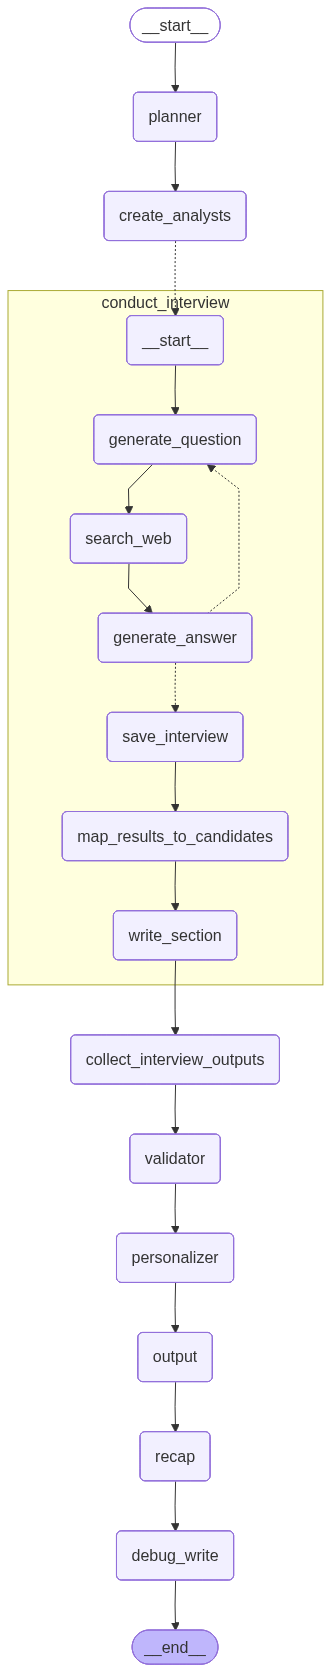

Personal Research Agent V2 graph compiled.


In [45]:
def initiate_all_interviews(state: ResearchGraphState):
    plan = state["planner_plan"]
    sends = []
    for analyst in state["analysts"]:
        if analyst.beat == "events" and not plan.include_events:
            continue
        if analyst.beat == "bitcoin" and not plan.include_bitcoin:
            continue
        sends.append(
            Send(
                "conduct_interview",
                {
                    "analyst": analyst,
                    "messages": [
                        HumanMessage(content=f"You are preparing Personal Research Agent V2 digest for: {state.get('user_request', '')}")
                    ],
                },
            )
        )
    return sends


def collect_interview_outputs(state: ResearchGraphState) -> Dict[str, Any]:
    return {
        "trace_events": [{
            "stage": "collect_interview_outputs",
            "section_count": len(state.get("sections", [])),
            "candidate_count": len(state.get("candidate_items", [])),
        }]
    }


main_builder = StateGraph(ResearchGraphState)

main_builder.add_node("planner", planner_node)
main_builder.add_node("create_analysts", create_analysts)
main_builder.add_node("conduct_interview", interview_graph)
main_builder.add_node("collect_interview_outputs", collect_interview_outputs)
main_builder.add_node("validator", validate_candidates)
main_builder.add_node("personalizer", personalize_and_rank)
main_builder.add_node("output", build_output)
main_builder.add_node("recap", build_multilingual_recap)
main_builder.add_node("debug_write", write_debug_outputs)

main_builder.add_edge(START, "planner")
main_builder.add_edge("planner", "create_analysts")
main_builder.add_conditional_edges("create_analysts", initiate_all_interviews, ["conduct_interview"])

main_builder.add_edge("conduct_interview", "collect_interview_outputs")
main_builder.add_edge("collect_interview_outputs", "validator")
main_builder.add_edge("validator", "personalizer")
main_builder.add_edge("personalizer", "output")
main_builder.add_edge("output", "recap")
main_builder.add_edge("recap", "debug_write")
main_builder.add_edge("debug_write", END)

memory = MemorySaver()
main_graph = main_builder.compile(checkpointer=memory)

try:
    display(Image(main_graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    print("Graph render unavailable in this environment:", e)

print("Personal Research Agent V2 graph compiled.")


## 9) Demo Run


In [46]:
demo_input = {
    "user_request": (
        "Prepare my Personal Research Agent V2 digest with emphasis on Netherlands and Limburg news, "
        "family-friendly weekend events near Maastricht, and fresh Bitcoin market/technical/community signals."
    )
}

result = main_graph.invoke(
    demo_input,
    config={"configurable": {"thread_id": "personal-research-agent-v2-demo"}}
)

display(Markdown("## Personal Research Agent V2 Report"))
display(Markdown(result.get("final_report", "")))

display(Markdown("## Personal Research Agent V2 Newsletter"))
display(Markdown(result.get("final_newsletter", "")))

print("validated_items:", len(result.get("validated_items", [])))
print("rejected_items:", len(result.get("rejected_items", [])))
print("scored_items:", len(result.get("scored_items", [])))


/tmp/ipykernel_404024/1397890461.py:147: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = f"v2-{datetime.utcnow().strftime('%Y%m%d%H%M%S')}"
/tmp/ipykernel_404024/1397890461.py:150: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


## Personal Research Agent V2 Report

# Personal Research Agent V2 Report

## Introduction

This report provides an analysis of Bitcoin network signals and socio-economic news for the Netherlands. The research aimed to integrate these topics with local news from Limburg and family-friendly events in Maastricht. However, significant data gaps were identified, with no relevant, current information retrieved for the local news and events categories. The following insights are based on the validated data available.

## Insights

### Bitcoin Network & Market

The Bitcoin ecosystem shows strong fundamentals, driven by two key areas. Firstly, institutional demand remains a primary market driver, largely influenced by the performance of US spot Bitcoin ETFs. Secondly, the core network development is active and robust. The successful testing of the Bitcoind v30.0rc1 release candidate and a continuous, active Bitcoin Improvement Proposal (BIP) process demonstrate ongoing technical innovation and network maintenance.

### Netherlands National News

Several socio-economic trends are prominent at the national level. There is an ongoing public and political discussion concerning poverty and the cost of living. Concurrently, projections indicate that the Netherlands will host approximately 1.2 million migrant workers by 2030, highlighting significant demographic and labor market shifts. These trends are contextualized by various new laws and tax changes implemented in 2024.

### Local News & Events (Limburg/Maastricht)

No specific, current items were identified for local news in the Limburg region or for family-friendly weekend events near Maastricht. This represents a critical data retrieval failure in this cycle, limiting the report's utility for local and personal planning.

## Conclusion

The analysis confirms that the Bitcoin network is fundamentally healthy, with active development and sustained institutional interest. At a national level in the Netherlands, key socio-economic topics include poverty and labor migration. The inability to retrieve requested local information for Limburg and Maastricht is the primary limitation of this report, preventing an integrated view of the user's personal and financial landscape.

## Sources

-   bitcoin/bitcoin - GitHub Issue #33368: v30.0 Testing
-   bitcoin/bips - GitHub: Active Bitcoin Improvement Proposals
-   DutchNews.nl: What's all the fuss about poverty in the Netherlands?
-   NL Times: Netherlands to count 1.2 million migrant workers by 2030

---
# Personal Newsletter

**Your Weekly Briefing: Bitcoin Tech & Dutch Trends**

Hi there,

Here is your weekly intelligence briefing, focusing on key signals in the Bitcoin network and notable developments across the Netherlands.

### Bitcoin Update: Strong & Steady

The Bitcoin network's foundation remains strong. Developers are actively testing new software versions (v30.0rc1) to ensure security and performance. This technical diligence runs in parallel with the major market trend: continued interest from large institutions, largely driven by the new US-based Bitcoin ETFs.

### The Netherlands: Economic & Social Shifts

On the national front, there's a significant conversation happening around poverty and the cost of living. At the same time, new projections show the number of migrant workers in the country is expected to reach 1.2 million by 2030, signaling major changes for the labor market and society.

### Your Weekend in Maastricht

I was unable to find specific family-friendly events for the upcoming weekend in the Maastricht area. I recommend checking local community boards or venue websites directly for the most current listings.

Have a great week.

---
# Multilingual Recap

**EN**
*   **Bitcoin:** Robust technical development continues with new software testing, supported by strong institutional market interest.
*   **Netherlands:** Key national topics include discussions on poverty and projections of a significant increase in migrant workers by 2030.
*   **Local:** No specific news for Limburg or family-friendly events for Maastricht were identified in this search.

**IT**
*   **Bitcoin:** Prosegue il robusto sviluppo tecnico con test di nuovo software, supportato da un forte interesse di mercato istituzionale.
*   **Paesi Bassi:** I temi nazionali chiave includono il dibattito sulla povertà e le proiezioni di un aumento significativo dei lavoratori migranti entro il 2030.
*   **Locale:** In questa ricerca non sono state identificate notizie specifiche per il Limburgo o eventi per famiglie a Maastricht.

**NL**
*   **Bitcoin:** Robuuste technische ontwikkeling gaat door met het testen van nieuwe software, ondersteund door sterke institutionele marktinteresse.
*   **Nederland:** Belangrijke nationale onderwerpen zijn discussies over armoede en de verwachting van een aanzienlijke toename van arbeidsmigranten tegen 2030.
*   **Lokaal:** Er is geen specifiek nieuws voor Limburg of gezinsvriendelijke evenementen voor Maastricht gevonden in deze zoekopdracht.

## Personal Research Agent V2 Newsletter

# Personal Research Agent V2 Newsletter (2026-04-22)

## Quick Glance
- News signals: **4**
- Weekend events: **0**
- Bitcoin signals: **2**
- Quality gate: **WARN** (mode: `soft`) (missing targets: news=0, events=2, bitcoin=0)

## Netherlands & Local News
- **1. [What's all the fuss about poverty in the Netherlands? - DutchNews.nl](https://www.dutchnews.nl/2024/10/whats-all-the-fuss-about-poverty-in-the-netherlands)** (source: `dutchnews.nl`, tier: `tier1`, type: `article`, score: `0.85`) - The richest Dutch are getting richer, adding 5% to their wealth last year, according to the latest edition of the Quote 500 rich list.
- **2. [Netherlands to count 1.2 million migrant workers by 2030 | NL Times](https://nltimes.nl/2022/06/21/netherlands-count-12-million-migrant-workers-2030)** (source: `nltimes.nl`, tier: `tier2`, type: `article`, score: `0.81`) - The Netherlands is facing staff shortages in almost all sectors of its economy. Getting more workers from abroad may be a solution to that.
- **3. [Record-breaking 39.5 degrees in Maastricht, as asphalt reaches 52 ...](https://nltimes.nl/2022/07/19/record-breaking-395-degrees-maastricht-asphalt-reaches-52-degrees-people-flock-movies)** (source: `nltimes.nl`, tier: `tier2`, type: `article`, score: `0.80`) - The old record of 37.1 degrees Celsius, measured in 2006 in Westdorpe, was broken at around 1:50 pm when the temperature in Maastricht reached 37.3 degrees.
- **4. [New laws, new taxes: what changes for you in 2024 - DutchNews.nl](https://www.dutchnews.nl/2024/01/new-laws-new-taxes-what-changes-for-you-in-2024)** (source: `dutchnews.nl`, tier: `tier1`, type: `article`, score: `0.77`) - Households will get a standard €28.31 cut energy taxes. Taxes rise on soft drinks, fruit juice and plant-based milks. The tax on soft drinks,

## Weekend Events (2026-04-25 to 2026-04-26)
- No reliable nearby weekend event found for this run.

## Bitcoin Corner
- **1. [v30.0 Testing · Issue #33368 · bitcoin/bitcoin - GitHub](https://github.com/bitcoin/bitcoin/issues/33368)** (source: `github.com`, tier: `tier1`, type: `technical`, score: `1.00`) - Upgraded bitcoind from version 29.0 to 30.0rc1. Bitcoind (30.0rc1) is working great (txindex=1) with low block verification times (about 1
- **2. [Mining interface tracking issue #33777 - bitcoin/bitcoin - GitHub](https://github.com/bitcoin/bitcoin/issues/33777)** (source: `github.com`, tier: `tier1`, type: `technical`, score: `1.00`) - These are bug fixes, not new features. Except for #34568 (already merged) they are not breaking changes, so they if they don't make it into v31.

## Action Checklist
- Pick one local event to attend this weekend.
- Review two high-signal news items and note personal impact.
- Track one Bitcoin market signal and one technical/community signal.

## Sources
- [dutchnews.nl](https://www.dutchnews.nl/2024/10/whats-all-the-fuss-about-poverty-in-the-netherlands)
- [nltimes.nl](https://nltimes.nl/2022/06/21/netherlands-count-12-million-migrant-workers-2030)
- [nltimes.nl](https://nltimes.nl/2022/07/19/record-breaking-395-degrees-maastricht-asphalt-reaches-52-degrees-people-flock-movies)
- [dutchnews.nl](https://www.dutchnews.nl/2024/01/new-laws-new-taxes-what-changes-for-you-in-2024)
- [github.com](https://github.com/bitcoin/bitcoin/issues/33368)
- [github.com](https://github.com/bitcoin/bitcoin/issues/33777)

validated_items: 11
rejected_items: 19
scored_items: 11


## 10) Validation and Acceptance Checks


In [47]:
assert isinstance(result.get("final_report", ""), str) and len(result.get("final_report", "")) > 0
assert isinstance(result.get("final_newsletter", ""), str) and len(result.get("final_newsletter", "")) > 0

assert isinstance(result.get("validated_items", []), list)
assert isinstance(result.get("rejected_items", []), list)
assert isinstance(result.get("scored_items", []), list)

quality_gate_status = result.get("quality_gate_status", {})
assert quality_gate_status.get("status") in {"pass", "warn"}
if quality_gate_status.get("status") == "warn":
    print("Quality gate warning:", quality_gate_status)

recap = result.get("multilingual_recap")
assert recap and recap.english and recap.italian and recap.dutch

assert (DEBUG_DIR / "rejected_items.json").exists()
assert (DEBUG_DIR / "last_run_trace.json").exists()
assert (DEBUG_DIR / "manual_validation_checklist.md").exists()

trace_payload = load_json(DEBUG_DIR / "last_run_trace.json", {})
assert "reasoning_active" in trace_payload
assert "reasoning_preflight_ok" in trace_payload

print("V2 runtime checks passed.")


Quality gate warning: {'status': 'warn', 'targets': {'news': 3, 'events': 2, 'bitcoin': 2}, 'selected': {'news': 4, 'events': 0, 'bitcoin': 2}, 'missing': {'news': 0, 'events': 2, 'bitcoin': 0}, 'bitcoin_diversity_ok': False, 'mode': 'soft'}
V2 runtime checks passed.


## 11) Deterministic Unit-Like Checks (No API Call Required)


In [48]:
sample = CandidateItem(
    domain="news",
    title="Limburg tax policy update 2026-04-20",
    source="nos.nl",
    url="https://nos.nl/example-limburg-tax",
    summary="Recent policy update for Limburg households.",
    raw_snippet="Recent policy update for Limburg households.",
    published_date="2026-04-20",
    location_hint="Limburg",
    category="economy",
    content_type="article",
    base_score=0.8,
)

sample_tier = source_tier(sample)
assert sample_tier in {"tier1", "tier2", "unknown"}
ok, _, conf, _, _ = passes_freshness(sample, sample_tier, listing=False)
assert ok is True
assert conf > 0.0

tech = CandidateItem(
    domain="bitcoin",
    title="BIP review pull request",
    source="github.com",
    url="https://github.com/bitcoin/bips/pull/1234",
    summary="Discusses consensus rules",
    raw_snippet="Discusses consensus rules",
    category="technical",
    content_type="technical",
)
assert bitcoin_technical_signal_ok(tech) is True
assert url_pattern_match(tech) == ""

event_listing = CandidateItem(
    domain="events",
    title="Things to do in Maastricht",
    source="allevents.in",
    url="https://allevents.in/maastricht/events--this-weekend",
    summary="Discover all events",
    raw_snippet="Discover all events",
    content_type="event",
)
assert is_listing_page(event_listing) is True
assert url_pattern_match(event_listing) != ""

btc_mismatch = CandidateItem(
    domain="bitcoin",
    title="Healthy Habits Meetup Group",
    source="meetup.com",
    url="https://meetup.com/topics/habits/nl",
    summary="Community discussion and groups",
    raw_snippet="Community discussion and groups",
    category="community",
    content_type="community",
)
assert title_topic_alignment(btc_mismatch) is False

dup_a = canonical_item_id("https://example.com/a", "X")
dup_b = canonical_item_id("https://example.com/a/", "Y")
assert dup_a == dup_b

assert normalize_reason("unexpected_reason") == "generic_listing"
assert all(r.reason in VALID_REASON_CODES for r in result.get("rejected_items", []))

# Quality gate soft/hard behavior check
_original_hard_gate = MODEL_CONFIG.get("hard_fail_on_quality_gate", False)
try:
    MODEL_CONFIG["hard_fail_on_quality_gate"] = False
    soft_gate = personalize_and_rank({"validated_items": []})
    assert soft_gate["quality_gate_status"]["status"] == "warn"
    assert soft_gate["quality_gate_status"]["mode"] == "soft"

    MODEL_CONFIG["hard_fail_on_quality_gate"] = True
    hard_failed = False
    try:
        personalize_and_rank({"validated_items": []})
    except AssertionError as exc:
        hard_failed = "Quality gate hard fail" in str(exc)
    assert hard_failed is True
finally:
    MODEL_CONFIG["hard_fail_on_quality_gate"] = _original_hard_gate


news_queries = build_queries_for_beat("news")
assert all(all(term not in q.lower() for term in NEWS_QUERY_BANNED_TERMS) for q in news_queries)
assert any("latest" in q.lower() or "today" in q.lower() or "last 24 hours" in q.lower() for q in news_queries)

events_queries = build_queries_for_beat("events")
assert any(all(k in q.lower() for k in ["date", "location", "time"]) for q in events_queries)

va = ValidatedItem(
    item_id="a", domain="bitcoin", title="Release testing issue", source="github.com",
    url="https://github.com/bitcoin/bitcoin/issues/12345", summary="release testing",
    classification="analysis", category="technical", content_type="technical", score_total=0.5,
    recency_score=0.5, trust_score=0.5, geo_score=0.5, category_score=0.5, novelty_score=0.5
)
vc = va.model_copy(update={"item_id": "c", "url": "https://github.com/bitcoin/bips/blob/master/bip-0001.mediawiki", "title": "BIP-0001", "summary": "Foundational specification"})
assert bitcoin_value_band(va) == "A"
assert bitcoin_value_band(vc) == "C"

print("Deterministic checks passed.")


Deterministic checks passed.
